In [4]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from patchy_reionization import Cl_phiphi_toy, Cl_tautau_toy, R_tau_toy
from patchy_reionization import SolveConfig, X_REI
from patchy_reionization import compute_A_from_solution, compute_A_unit, solve_phi_background


scan_config = SolveConfig(
    z_ini=1.0e7,
    method="DOP853",
    rtol=1.0e-9,
    atol_rel=1.0e-12,
    dense_output=True,
)

linearity_config = SolveConfig(
    z_ini=1.0e5,
    method="DOP853",
    rtol=1.0e-9,
    atol_rel=1.0e-12,
    dense_output=True,
)


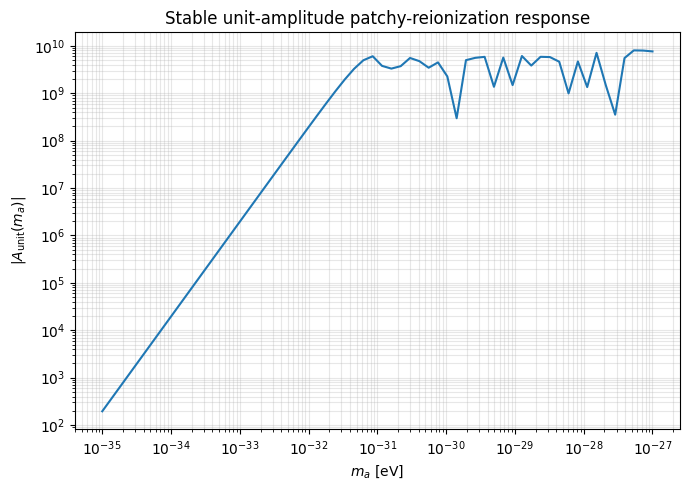

Picked mass = 5.3556669177069075e-28 eV
A_unit      = 8.0427857133315420e+09


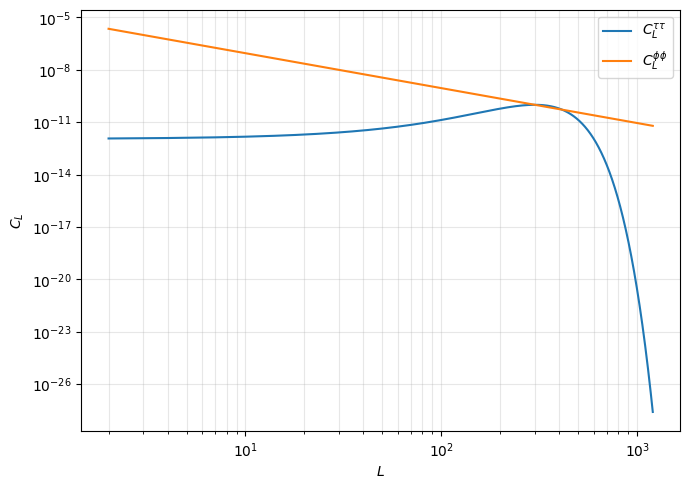

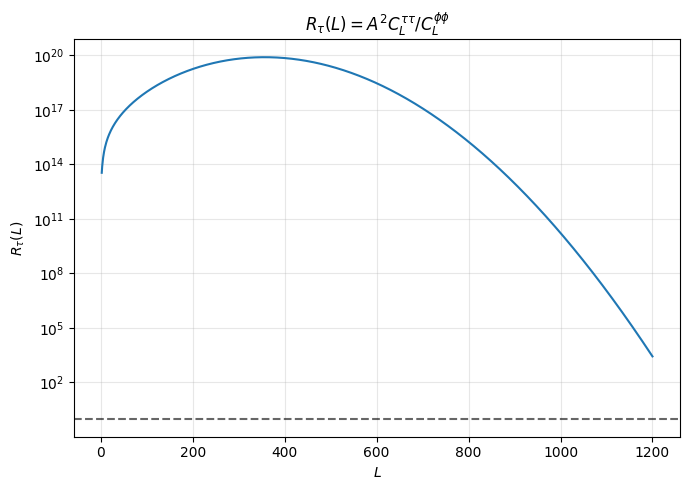

max R_tau = 7.7870525832806400e+19
at L = 356


In [5]:
m_grid = np.logspace(-35, -27, 60)
A_unit_vals = np.array([compute_A_unit(m_eV=m, config=scan_config) for m in m_grid])

plt.figure(figsize=(7, 5))
plt.loglog(m_grid, np.abs(A_unit_vals))
plt.xlabel(r"$m_a \ [{\rm eV}]$")
plt.ylabel(r"$|A_{\rm unit}(m_a)|$")
plt.title("Stable unit-amplitude patchy-reionization response")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

idx = np.nanargmax(np.abs(A_unit_vals))
m_pick = m_grid[idx]
A_pick = A_unit_vals[idx]

print(f"Picked mass = {m_pick:.16e} eV")
print(f"A_unit      = {A_pick:.16e}")

L = np.arange(2, 1201)
Cl_tau = Cl_tautau_toy(L, Ctau0=1e-10, Lc=300.0, sigmaL=100.0)
Cl_phi = Cl_phiphi_toy(L, Cphi0=1e-10, Lstar=300.0, nphi=2.0, Lcut=None)
R = R_tau_toy(
    L,
    A_pick,
    Ctau0=1e-10,
    Lc=300.0,
    sigmaL=100.0,
    Cphi0=1e-10,
    Lstar=300.0,
    nphi=2.0,
    Lcut=None,
)

plt.figure(figsize=(7, 5))
plt.loglog(L, Cl_tau, label=r"$C_L^{\tau\tau}$")
plt.loglog(L, Cl_phi, label=r"$C_L^{\phi\phi}$")
plt.xlabel(r"$L$")
plt.ylabel(r"$C_L$")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.semilogy(L, np.abs(R))
plt.axhline(1.0, ls="--", color="black", alpha=0.6)
plt.xlabel(r"$L$")
plt.ylabel(r"$R_\tau(L)$")
plt.title(r"$R_\tau(L)=A^2 C_L^{\tau\tau}/C_L^{\phi\phi}$")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"max R_tau = {np.nanmax(np.abs(R)):.16e}")
print(f"at L = {L[np.nanargmax(np.abs(R))]}")


phi_ini           legacy_A          robust_A          unit_rescaled      robust/unit-1     legacy/unit-1
--------------------------------------------------------------------------------------------------------
 1.000e+00      2.334221e+09      8.042814e+09      8.042814e+09      0.000000e+00     -7.097756e-01
 1.000e-03      2.334221e+06      8.042814e+06      8.042814e+06     -1.463274e-13     -7.097756e-01
 1.000e-06      2.334221e+03      8.042814e+03      8.042814e+03     -1.115774e-13     -7.097756e-01
 1.000e-09      2.334221e+00      8.042814e+00      8.042814e+00     -2.160494e-13     -7.097756e-01


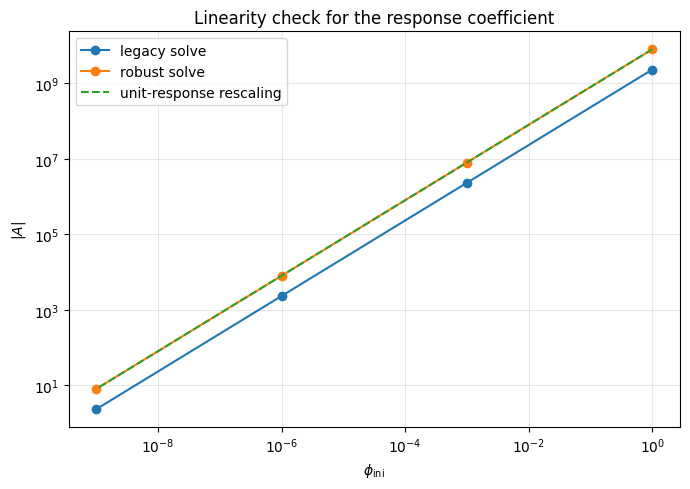

In [6]:
def compute_legacy_A(m_eV, phi_ini, z_ini=1.0e5):
    legacy_config = SolveConfig(
        z_ini=z_ini,
        method="RK45",
        rtol=1.0e-8,
        atol_rel=1.0e-10,
        dense_output=False,
        n_eval=4000,
    )
    sol = solve_phi_background(m_eV=m_eV, phi_ini=phi_ini, config=legacy_config)
    return compute_A_from_solution(sol, x_target=X_REI)


phi_ini_list = [1.0, 1.0e-3, 1.0e-6, 1.0e-9]
A_unit_linear = compute_A_unit(m_pick, config=linearity_config)

print("phi_ini           legacy_A          robust_A          unit_rescaled      robust/unit-1     legacy/unit-1")
print("-" * 104)

legacy_vals = []
robust_vals = []
unit_vals = []

for phi_ini in phi_ini_list:
    A_legacy = compute_legacy_A(m_pick, phi_ini=phi_ini, z_ini=1.0e5)
    sol = solve_phi_background(m_eV=m_pick, phi_ini=phi_ini, config=linearity_config)
    A_robust = compute_A_from_solution(sol, x_target=X_REI)
    A_unit_rescaled = A_unit_linear * phi_ini

    legacy_vals.append(A_legacy)
    robust_vals.append(A_robust)
    unit_vals.append(A_unit_rescaled)

    robust_rel = (A_robust / A_unit_rescaled) - 1.0
    legacy_rel = (A_legacy / A_unit_rescaled) - 1.0
    print(
        f"{phi_ini:10.3e}  "
        f"{A_legacy:16.6e}  "
        f"{A_robust:16.6e}  "
        f"{A_unit_rescaled:16.6e}  "
        f"{robust_rel:16.6e}  "
        f"{legacy_rel:16.6e}"
    )

plt.figure(figsize=(7, 5))
plt.loglog(phi_ini_list, np.abs(legacy_vals), "o-", label="legacy solve")
plt.loglog(phi_ini_list, np.abs(robust_vals), "o-", label="robust solve")
plt.loglog(phi_ini_list, np.abs(unit_vals), "--", label="unit-response rescaling")
plt.xlabel(r"$\phi_{\rm ini}$")
plt.ylabel(r"$|A|$")
plt.title("Linearity check for the response coefficient")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
test_masses = [1.0e-32, 1.0e-30, m_pick]

reference = SolveConfig(
    z_ini=1.0e5,
    method="DOP853",
    rtol=1.0e-10,
    atol_rel=1.0e-13,
    dense_output=True,
)
test_configs = [
    ("dop853_medium", SolveConfig(z_ini=1.0e5, method="DOP853", rtol=1.0e-9, atol_rel=1.0e-12, dense_output=True)),
    ("rk45_medium", SolveConfig(z_ini=1.0e5, method="RK45", rtol=1.0e-8, atol_rel=1.0e-11, dense_output=True)),
    ("rk45_loose", SolveConfig(z_ini=1.0e5, method="RK45", rtol=1.0e-7, atol_rel=1.0e-10, dense_output=True)),
]

print("mass_eV           config           A_unit            rel_diff_vs_ref")
print("-------------------------------------------------------------------")

for mass in test_masses:
    A_ref = compute_A_unit(mass, config=reference)
    print(f"{mass:12.4e}  {'reference':14s}  {A_ref:16.6e}  {0.0:16.6e}")
    for name, config in test_configs:
        A_val = compute_A_unit(mass, config=config)
        rel_diff = (A_val / A_ref) - 1.0
        print(f"{mass:12.4e}  {name:14s}  {A_val:16.6e}  {rel_diff:16.6e}")
    print()


mass_eV           config           A_unit            rel_diff_vs_ref
-------------------------------------------------------------------
  1.0000e-32  reference          -1.933963e+08      0.000000e+00
  1.0000e-32  dop853_medium      -1.933963e+08      4.564931e-10
  1.0000e-32  rk45_medium        -1.933963e+08      6.856802e-10
  1.0000e-32  rk45_loose         -1.933962e+08     -2.389250e-08

  1.0000e-30  reference           4.408707e+09      0.000000e+00
  1.0000e-30  dop853_medium       4.408707e+09      1.177421e-09
  1.0000e-30  rk45_medium         4.408707e+09     -3.425036e-08
  1.0000e-30  rk45_loose          4.408705e+09     -4.025321e-07

  5.3557e-28  reference           8.042809e+09      0.000000e+00
  5.3557e-28  dop853_medium       8.042814e+09      6.207571e-07
  5.3557e-28  rk45_medium         8.042174e+09     -7.890914e-05
  5.3557e-28  rk45_loose          8.036536e+09     -7.800050e-04

